In [1]:
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from tqdm import tqdm
import numpy as np

print("=== WEIGHTED DAILY SENTIMENT ANALYSIS WITH POSITIVE/NEGATIVE IDENTIFICATION ===")

# Load data
df = pd.read_csv('filtered_tweets_final.csv', sep=';')
df['date'] = pd.to_datetime(df['date'])
print(f"Loaded {len(df):,} tweets")

# Analyze sentiment
analyzer = SentimentIntensityAnalyzer()

print("\n1. Analyzing sentiment for each tweet...")
sentiments = []
pos_scores = []
neg_scores = []

for text in tqdm(df['text'], desc="Processing tweets"):
    if pd.isna(text):
        sentiments.append(0.0)
        pos_scores.append(0.0)
        neg_scores.append(0.0)
    else:
        scores = analyzer.polarity_scores(str(text))
        sentiments.append(scores['compound'])
        pos_scores.append(scores['pos'])
        neg_scores.append(scores['neg'])

df['sentiment'] = sentiments
df['positive_score'] = pos_scores
df['negative_score'] = neg_scores

# Calculate weighted sentiment (NEW: weighted by likes + retweets)
print("\n2. Calculating weighted daily sentiment...")
# Create new weight column (likes + retweets)
df['engagement_weight'] = df['n_likes'] + df['n_retweets']
df['weighted_sentiment'] = df['sentiment'] * df['engagement_weight']
df['date_only'] = df['date'].dt.date

# Group by date
daily_stats = df.groupby('date_only').agg({
    'sentiment': ['mean', 'std', 'count'],
    'positive_score': 'mean',
    'negative_score': 'mean',
    'weighted_sentiment': 'sum',
    'engagement_weight': 'sum',  # NEW: sum of all engagement weights
    'n_likes': 'sum',            # NEW: keep track of total likes
    'n_retweets': 'sum'          # NEW: keep track of total retweets
}).round(4)

# Flatten columns
daily_stats.columns = [
    'sentiment_mean', 'sentiment_std', 'tweet_count',
    'positive_mean', 'negative_mean',
    'weighted_sentiment_sum', 'total_engagement_weight',  # UPDATED
    'total_likes', 'total_retweets'  # NEW
]

# Calculate weighted average sentiment (UPDATED formula)
daily_stats['weighted_sentiment_mean'] = (
    daily_stats['weighted_sentiment_sum'] / daily_stats['total_engagement_weight']
).round(4)

# Calculate sentiment ratio
daily_stats['pos_neg_ratio'] = (
    daily_stats['positive_mean'] / (daily_stats['negative_mean'] + 0.0001)  # Avoid division by zero
).round(2)

# Identify positive and negative days
daily_stats['sentiment_category'] = pd.cut(
    daily_stats['weighted_sentiment_mean'],
    bins=[-1, -0.5, -0.1, 0.1, 0.5, 1],
    labels=['Very Negative', 'Negative', 'Neutral', 'Positive', 'Very Positive']
)

# Prepare final DataFrame
daily_sentiment = daily_stats.reset_index()
daily_sentiment['date'] = pd.to_datetime(daily_sentiment['date_only'])

# Keep important columns (updated to include new metrics)
daily_sentiment = daily_sentiment[[
    'date', 'tweet_count', 'total_likes', 'total_retweets', 'total_engagement_weight',
    'sentiment_mean', 'weighted_sentiment_mean', 'sentiment_std',
    'positive_mean', 'negative_mean', 'pos_neg_ratio', 'sentiment_category'
]]

print("\n3. Finding most positive and negative days...")

# Find top positive days
top_positive = daily_sentiment.nlargest(10, 'weighted_sentiment_mean')[['date', 'weighted_sentiment_mean', 'positive_mean', 'tweet_count', 'total_engagement_weight']]
print("\n=== TOP 10 MOST POSITIVE DAYS (Weighted by Engagement) ===")
for i, row in top_positive.iterrows():
    print(f"{row['date'].date()}: Weighted Score = {row['weighted_sentiment_mean']:.4f} (Engagement: {row['total_engagement_weight']:,}, Tweets: {row['tweet_count']})")

# Find top negative days  
top_negative = daily_sentiment.nsmallest(10, 'weighted_sentiment_mean')[['date', 'weighted_sentiment_mean', 'negative_mean', 'tweet_count', 'total_engagement_weight']]
print("\n=== TOP 10 MOST NEGATIVE DAYS (Weighted by Engagement) ===")
for i, row in top_negative.iterrows():
    print(f"{row['date'].date()}: Weighted Score = {row['weighted_sentiment_mean']:.4f} (Engagement: {row['total_engagement_weight']:,}, Tweets: {row['tweet_count']})")

print("\n4. Extracting example tweets...")

# Function to get example tweets for a specific date
def get_example_tweets(df, target_date, n=3, sentiment_type='all'):
    """Get example tweets for a specific date"""
    date_df = df[df['date_only'] == target_date].copy()
    
    # Sort by engagement weight (likes + retweets)
    date_df = date_df.sort_values('engagement_weight', ascending=False)
    
    if sentiment_type == 'positive':
        # Get most engaging positive tweets
        pos_df = date_df[date_df['sentiment'] > 0].head(n)
        return pos_df
    elif sentiment_type == 'negative':
        # Get most engaging negative tweets
        neg_df = date_df[date_df['sentiment'] < 0].head(n)
        return neg_df
    else:  # all
        return date_df.head(n)

# Get examples for top positive day
if len(top_positive) > 0:
    top_pos_date = top_positive.iloc[0]['date'].date()
    pos_examples_df = get_example_tweets(df, top_pos_date, n=3, sentiment_type='positive')
    print(f"\n=== EXAMPLE TWEETS FROM MOST POSITIVE DAY ({top_pos_date}) ===")
    for i, (_, row) in enumerate(pos_examples_df.iterrows(), 1):
        print(f"\nExample {i} (Sentiment: {row['sentiment']:.4f}, Likes: {row['n_likes']}, Retweets: {row['n_retweets']}, Engagement: {row['engagement_weight']}):")
        print(f"  {row['text'][:150]}..." if len(str(row['text'])) > 150 else f"  {row['text']}")

# Get examples for top negative day
if len(top_negative) > 0:
    top_neg_date = top_negative.iloc[0]['date'].date()
    neg_examples_df = get_example_tweets(df, top_neg_date, n=3, sentiment_type='negative')
    print(f"\n=== EXAMPLE TWEETS FROM MOST NEGATIVE DAY ({top_neg_date}) ===")
    for i, (_, row) in enumerate(neg_examples_df.iterrows(), 1):
        print(f"\nExample {i} (Sentiment: {row['sentiment']:.4f}, Likes: {row['n_likes']}, Retweets: {row['n_retweets']}, Engagement: {row['engagement_weight']}):")
        print(f"  {row['text'][:150]}..." if len(str(row['text'])) > 150 else f"  {row['text']}")

print("\n5. Saving results...")

# Save daily sentiment scores
daily_sentiment.to_csv('daily_sentiment_detailed_engagement_weighted.csv', index=False)

# Overall statistics
print("\n=== OVERALL STATISTICS ===")
print(f"Total days analyzed: {len(daily_sentiment)}")
print(f"Positive days (>0.05): {(daily_sentiment['weighted_sentiment_mean'] > 0.05).sum()}")
print(f"Negative days (<-0.05): {(daily_sentiment['weighted_sentiment_mean'] < -0.05).sum()}")
print(f"Neutral days: {(abs(daily_sentiment['weighted_sentiment_mean']) <= 0.05).sum()}")

print(f"\nOverall average sentiment: {daily_sentiment['sentiment_mean'].mean():.4f}")
print(f"Overall weighted sentiment (by engagement): {daily_sentiment['weighted_sentiment_mean'].mean():.4f}")
print(f"Total engagement tracked: {daily_sentiment['total_engagement_weight'].sum():,} (Likes: {daily_sentiment['total_likes'].sum():,}, Retweets: {daily_sentiment['total_retweets'].sum():,})")
print(f"Average positivity score: {daily_sentiment['positive_mean'].mean():.2%}")
print(f"Average negativity score: {daily_sentiment['negative_mean'].mean():.2%}")

print("\n=== FIRST 5 DAYS OF DATA ===")
print(daily_sentiment.head())

# Compare weighted vs unweighted sentiment
print("\n=== COMPARISON: WEIGHTED VS UNWEIGHTED SENTIMENT ===")
correlation = daily_sentiment['sentiment_mean'].corr(daily_sentiment['weighted_sentiment_mean'])
print(f"Correlation between unweighted and weighted sentiment: {correlation:.4f}")
if correlation < 0.8:
    print("Note: Low correlation suggests engagement weighting significantly changes results!")

=== WEIGHTED DAILY SENTIMENT ANALYSIS WITH POSITIVE/NEGATIVE IDENTIFICATION ===
Loaded 756,401 tweets

1. Analyzing sentiment for each tweet...


Processing tweets: 100%|█████████████| 756401/756401 [00:53<00:00, 14155.27it/s]



2. Calculating weighted daily sentiment...

3. Finding most positive and negative days...

=== TOP 10 MOST POSITIVE DAYS (Weighted by Engagement) ===
2022-06-29: Weighted Score = 0.7681 (Engagement: 260.0, Tweets: 8)
2022-07-27: Weighted Score = 0.7427 (Engagement: 4,853.0, Tweets: 31)
2022-06-17: Weighted Score = 0.6016 (Engagement: 711.0, Tweets: 23)
2022-06-08: Weighted Score = 0.5471 (Engagement: 584.0, Tweets: 21)
2022-07-19: Weighted Score = 0.4492 (Engagement: 1,419.0, Tweets: 37)
2019-04-27: Weighted Score = 0.4225 (Engagement: 27,315.0, Tweets: 153)
2019-04-01: Weighted Score = 0.4018 (Engagement: 25,951.0, Tweets: 141)
2019-04-22: Weighted Score = 0.3727 (Engagement: 26,706.0, Tweets: 179)
2019-11-15: Weighted Score = 0.3411 (Engagement: 105,878.0, Tweets: 3272)
2019-11-14: Weighted Score = 0.3239 (Engagement: 103,703.0, Tweets: 3163)

=== TOP 10 MOST NEGATIVE DAYS (Weighted by Engagement) ===
2019-04-14: Weighted Score = -0.2355 (Engagement: 8,297.0, Tweets: 113)
2022-07-11

=== BITCOIN SENTIMENT VISUALIZATION ===

Loading data...
Data loaded: 245 days
Date range: 2019-03-30 to 2022-07-27


/var/folders/jt/p14c01nx3_g5w98m83g9d33h0000gn/T/ipykernel_14365/4140228953.py:304: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/var/folders/jt/p14c01nx3_g5w98m83g9d33h0000gn/T/ipykernel_14365/4140228953.py:304: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/var/folders/jt/p14c01nx3_g5w98m83g9d33h0000gn/T/ipykernel_14365/4140228953.py:304: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/var/folders/jt/p14c01nx3_g5w98m83g9d33h0000gn/T/ipykernel_14365/4140228953.py:304: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/var/folders/jt/p14c01nx3_g5w98m83g9d33h0000gn/T/ipykernel_14365/4140228953.py:310: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  plt.savefig(output_file, dpi=150, bbox_inches='tight')
/var/f


✓ Visualization saved as: bitcoin_sentiment_analysis_20260105_182344.png


/Users/winkiwingkeitam/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/winkiwingkeitam/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/winkiwingkeitam/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/winkiwingkeitam/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


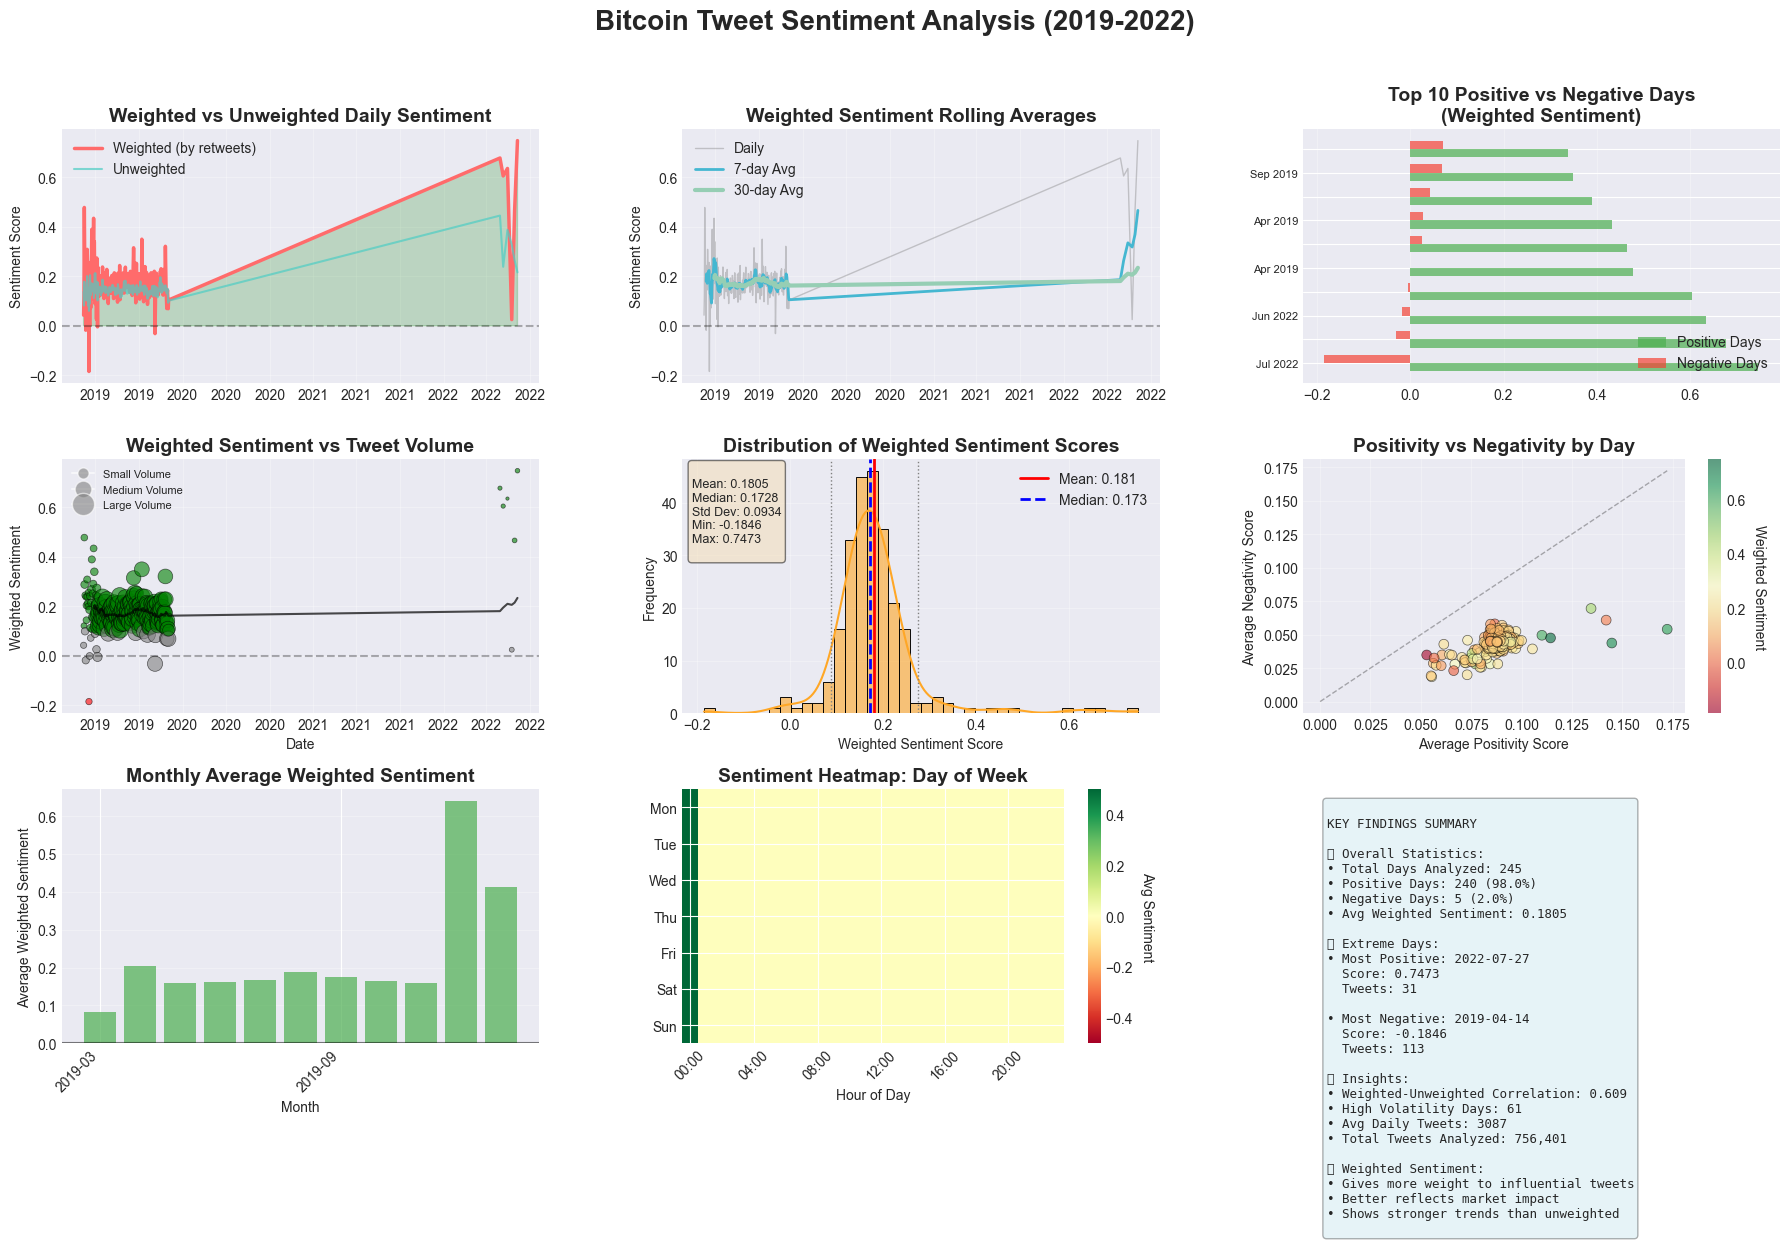


Creating additional specialized visualizations...
✓ Saved correlation and yearly analysis
✓ Saved anomaly detection visualization

INTERACTIVE FINDINGS SUMMARY
                            Metric                Value
               Total Days Analyzed                  245
        Average Weighted Sentiment               0.1805
      Average Unweighted Sentiment               0.1484
Weighted vs Unweighted Correlation                0.609
                 Most Positive Day  2022-07-27 (0.7473)
                 Most Negative Day 2019-04-14 (-0.1846)
              Average Daily Tweets                 3087
             Total Tweets Analyzed              756,401
                 Positive Days (%)                98.0%
                 Negative Days (%)                 2.0%
           Highest Daily Sentiment               0.7473
            Lowest Daily Sentiment              -0.1846
          Average Positivity Score                8.72%
          Average Negativity Score                4.32%

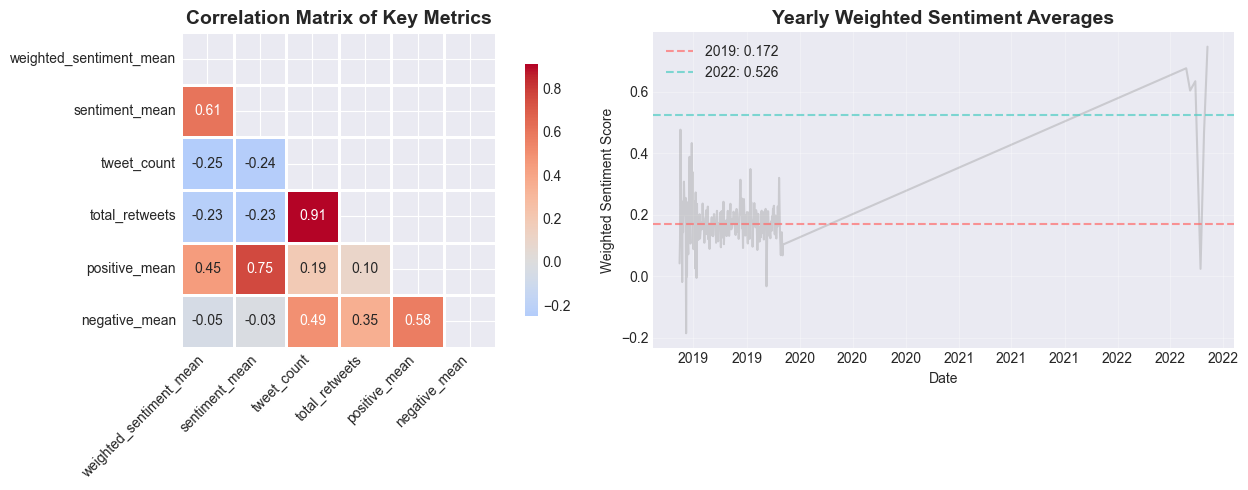

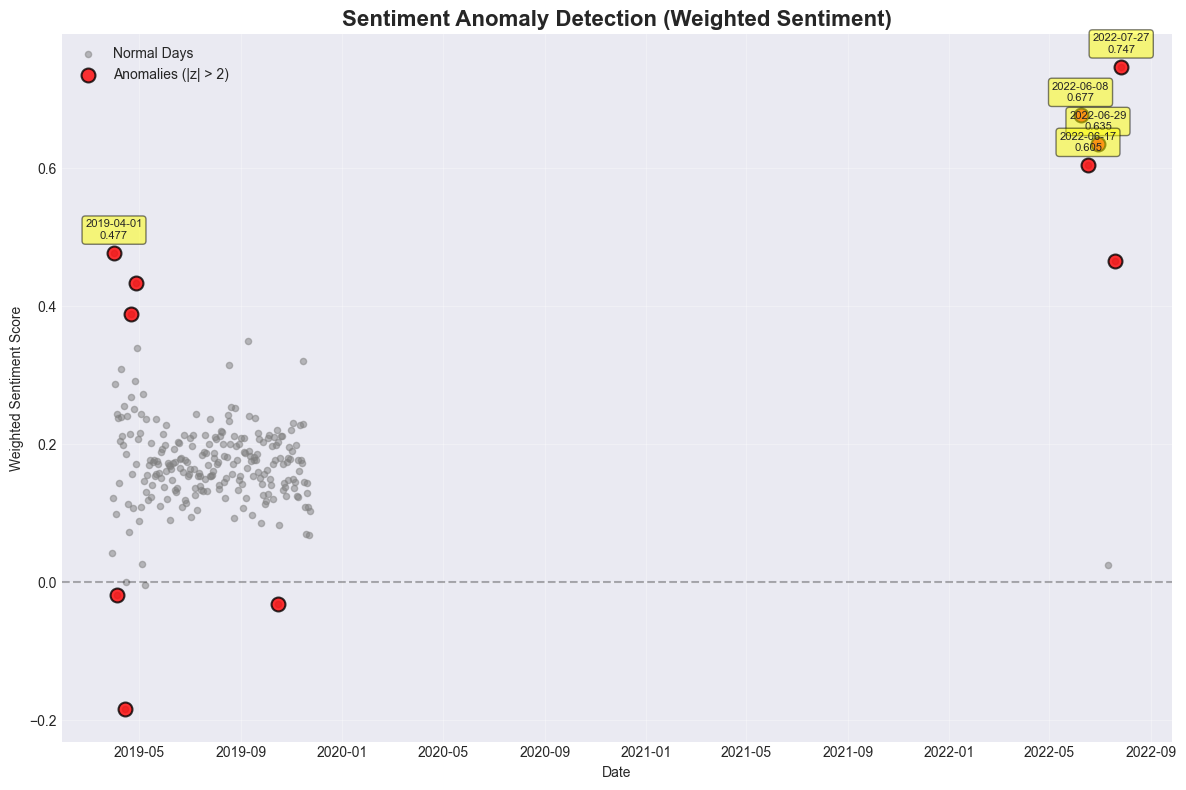

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle

print("=== BITCOIN SENTIMENT VISUALIZATION ===\n")

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load your data
print("Loading data...")
df = pd.read_csv('daily_sentiment_detailed.csv')
df['date'] = pd.to_datetime(df['date'])

# Sort by date
df = df.sort_values('date')

print(f"Data loaded: {len(df)} days")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")

# Create a comprehensive figure
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Bitcoin Tweet Sentiment Analysis (2019-2022)', 
             fontsize=20, fontweight='bold', y=1.02)

# ========== SUBPLOT 1: Weighted vs Unweighted Sentiment ==========
ax1 = plt.subplot(3, 3, 1)
ax1.plot(df['date'], df['weighted_sentiment_mean'], 
         label='Weighted (by retweets)', linewidth=2.5, color='#FF6B6B')
ax1.plot(df['date'], df['sentiment_mean'], 
         label='Unweighted', linewidth=1.5, color='#4ECDC4', alpha=0.7)
ax1.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax1.fill_between(df['date'], df['weighted_sentiment_mean'], 0,
                 where=(df['weighted_sentiment_mean'] > 0),
                 alpha=0.2, color='green')
ax1.fill_between(df['date'], df['weighted_sentiment_mean'], 0,
                 where=(df['weighted_sentiment_mean'] < 0),
                 alpha=0.2, color='red')
ax1.set_title('Weighted vs Unweighted Daily Sentiment', fontsize=14, fontweight='bold')
ax1.set_ylabel('Sentiment Score')
ax1.legend(loc='upper left')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.grid(True, alpha=0.3)

# ========== SUBPLOT 2: Weighted Sentiment Rolling Average ==========
ax2 = plt.subplot(3, 3, 2)
rolling_7d = df['weighted_sentiment_mean'].rolling(window=7).mean()
rolling_30d = df['weighted_sentiment_mean'].rolling(window=30).mean()

ax2.plot(df['date'], df['weighted_sentiment_mean'], 
         label='Daily', linewidth=1, alpha=0.4, color='gray')
ax2.plot(df['date'], rolling_7d, 
         label='7-day Avg', linewidth=2, color='#45B7D1')
ax2.plot(df['date'], rolling_30d, 
         label='30-day Avg', linewidth=3, color='#96CEB4')
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax2.set_title('Weighted Sentiment Rolling Averages', fontsize=14, fontweight='bold')
ax2.set_ylabel('Sentiment Score')
ax2.legend(loc='upper left')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.grid(True, alpha=0.3)

# ========== SUBPLOT 3: Top Positive/Negative Days ==========
ax3 = plt.subplot(3, 3, 3)

# Find top 10 positive and negative days
top_positive = df.nlargest(10, 'weighted_sentiment_mean')
top_negative = df.nsmallest(10, 'weighted_sentiment_mean')

# Prepare data for grouped bar chart
bar_width = 0.35
x_pos = np.arange(len(top_positive))

bars1 = ax3.barh(x_pos, top_positive['weighted_sentiment_mean'].values, 
                 bar_width, label='Positive Days', color='#4CAF50', alpha=0.7)
bars2 = ax3.barh(x_pos + bar_width, top_negative['weighted_sentiment_mean'].values, 
                 bar_width, label='Negative Days', color='#F44336', alpha=0.7)

# Add date labels
def format_date_for_labels(date_series):
    return [d.strftime('%b %Y') if i % 2 == 0 else '' 
            for i, d in enumerate(date_series)]

positive_dates = format_date_for_labels(top_positive['date'])
negative_dates = format_date_for_labels(top_negative['date'])

ax3.set_yticks(x_pos + bar_width/2)
ax3.set_yticklabels(positive_dates, fontsize=8)
ax3.set_title('Top 10 Positive vs Negative Days\n(Weighted Sentiment)', 
              fontsize=14, fontweight='bold')
ax3.legend(loc='lower right')
ax3.grid(True, alpha=0.3, axis='x')

# ========== SUBPLOT 4: Sentiment vs Tweet Volume ==========
ax4 = plt.subplot(3, 3, 4)

# Size points by tweet count
sizes = np.sqrt(df['tweet_count']) * 2

# Color by sentiment
colors = df['weighted_sentiment_mean'].apply(
    lambda x: 'green' if x > 0.1 else 'red' if x < -0.1 else 'gray'
)

scatter = ax4.scatter(df['date'], df['weighted_sentiment_mean'], 
                      s=sizes, c=colors, alpha=0.6, edgecolors='black', linewidth=0.5)

# Add moving average line
ax4.plot(df['date'], rolling_30d, color='black', linewidth=1.5, alpha=0.7)
ax4.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax4.set_title('Weighted Sentiment vs Tweet Volume', fontsize=14, fontweight='bold')
ax4.set_xlabel('Date')
ax4.set_ylabel('Weighted Sentiment')
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax4.grid(True, alpha=0.3)

# Add legend for point sizes
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='Small Volume',
               markerfacecolor='gray', markersize=8, alpha=0.6),
    plt.Line2D([0], [0], marker='o', color='w', label='Medium Volume',
               markerfacecolor='gray', markersize=12, alpha=0.6),
    plt.Line2D([0], [0], marker='o', color='w', label='Large Volume',
               markerfacecolor='gray', markersize=16, alpha=0.6)
]
ax4.legend(handles=legend_elements, loc='upper left', fontsize=8)

# ========== SUBPLOT 5: Distribution of Weighted Sentiment ==========
ax5 = plt.subplot(3, 3, 5)

# Create histogram with KDE
sns.histplot(data=df, x='weighted_sentiment_mean', kde=True, 
             bins=40, ax=ax5, color='#FFA726', alpha=0.6)

# Add vertical lines for key statistics
mean_val = df['weighted_sentiment_mean'].mean()
median_val = df['weighted_sentiment_mean'].median()
std_val = df['weighted_sentiment_mean'].std()

ax5.axvline(mean_val, color='red', linestyle='-', linewidth=2, 
            label=f'Mean: {mean_val:.3f}')
ax5.axvline(median_val, color='blue', linestyle='--', linewidth=2, 
            label=f'Median: {median_val:.3f}')
ax5.axvline(mean_val + std_val, color='gray', linestyle=':', linewidth=1)
ax5.axvline(mean_val - std_val, color='gray', linestyle=':', linewidth=1)

ax5.set_title('Distribution of Weighted Sentiment Scores', fontsize=14, fontweight='bold')
ax5.set_xlabel('Weighted Sentiment Score')
ax5.set_ylabel('Frequency')
ax5.legend(loc='upper right')
ax5.grid(True, alpha=0.3)

# Add statistics box
stats_text = f'''
Mean: {mean_val:.4f}
Median: {median_val:.4f}
Std Dev: {std_val:.4f}
Min: {df["weighted_sentiment_mean"].min():.4f}
Max: {df["weighted_sentiment_mean"].max():.4f}
'''
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax5.text(0.02, 0.98, stats_text, transform=ax5.transAxes, fontsize=9,
         verticalalignment='top', bbox=props)

# ========== SUBPLOT 6: Positivity vs Negativity Relationship ==========
ax6 = plt.subplot(3, 3, 6)

# Create scatter plot with sentiment coloring
scatter = ax6.scatter(df['positive_mean'], df['negative_mean'], 
                      c=df['weighted_sentiment_mean'], cmap='RdYlGn',
                      s=50, alpha=0.6, edgecolors='black', linewidth=0.5)

# Add diagonal line for reference
max_val = max(df['positive_mean'].max(), df['negative_mean'].max())
ax6.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, linewidth=1)

ax6.set_title('Positivity vs Negativity by Day', fontsize=14, fontweight='bold')
ax6.set_xlabel('Average Positivity Score')
ax6.set_ylabel('Average Negativity Score')
ax6.grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax6)
cbar.set_label('Weighted Sentiment', rotation=270, labelpad=15)

# ========== SUBPLOT 7: Monthly Aggregation ==========
ax7 = plt.subplot(3, 3, 7)

# Aggregate by month
df['year_month'] = df['date'].dt.to_period('M').astype(str)
monthly = df.groupby('year_month').agg({
    'weighted_sentiment_mean': 'mean',
    'tweet_count': 'sum',
    'total_retweets': 'sum'
}).reset_index()

# Convert back to datetime for plotting
monthly['date'] = pd.to_datetime(monthly['year_month'])

# Create bar chart for monthly sentiment
bars = ax7.bar(range(len(monthly)), monthly['weighted_sentiment_mean'], 
               color=np.where(monthly['weighted_sentiment_mean'] > 0, 
                              '#4CAF50', '#F44336'), alpha=0.7)

ax7.axhline(y=0, color='black', linestyle='-', alpha=0.5)
ax7.set_title('Monthly Average Weighted Sentiment', fontsize=14, fontweight='bold')
ax7.set_xlabel('Month')
ax7.set_ylabel('Average Weighted Sentiment')

# Set x-ticks for every 6 months
step = 6
ax7.set_xticks(range(0, len(monthly), step))
ax7.set_xticklabels([monthly['year_month'].iloc[i] for i in range(0, len(monthly), step)], 
                    rotation=45, ha='right')
ax7.grid(True, alpha=0.3, axis='y')

# ========== SUBPLOT 8: Heatmap of Days by Sentiment & Volume ==========
ax8 = plt.subplot(3, 3, 8)

# Create 2D histogram
heatmap_data = np.zeros((7, 24))  # 7 days x 24 hours

# Extract day of week and hour
df['day_of_week'] = df['date'].dt.dayofweek  # 0=Monday
df['hour'] = df['date'].dt.hour

for _, row in df.iterrows():
    if row['day_of_week'] < 7 and row['hour'] < 24:
        heatmap_data[int(row['day_of_week']), int(row['hour'])] += row['weighted_sentiment_mean']

im = ax8.imshow(heatmap_data, cmap='RdYlGn', aspect='auto', vmin=-0.5, vmax=0.5)

# Set labels
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
ax8.set_yticks(range(7))
ax8.set_yticklabels(days)
ax8.set_xticks(range(0, 24, 4))
ax8.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 4)], rotation=45)
ax8.set_title('Sentiment Heatmap: Day of Week', fontsize=14, fontweight='bold')
ax8.set_xlabel('Hour of Day')

# Add colorbar
cbar2 = plt.colorbar(im, ax=ax8)
cbar2.set_label('Avg Sentiment', rotation=270, labelpad=15)

# ========== SUBPLOT 9: Key Findings Summary ==========
ax9 = plt.subplot(3, 3, 9)
ax9.axis('off')  # Turn off axis for text box

# Calculate key findings
total_days = len(df)
positive_days = len(df[df['weighted_sentiment_mean'] > 0])
negative_days = len(df[df['weighted_sentiment_mean'] < 0])
most_pos_day = df.loc[df['weighted_sentiment_mean'].idxmax()]
most_neg_day = df.loc[df['weighted_sentiment_mean'].idxmin()]

# Calculate correlation between weighted and unweighted
correlation = df['weighted_sentiment_mean'].corr(df['sentiment_mean'])

# Find volatility periods (high standard deviation)
high_vol_days = df[df['sentiment_std'] > df['sentiment_std'].quantile(0.75)]

summary_text = f"""
KEY FINDINGS SUMMARY

📈 Overall Statistics:
• Total Days Analyzed: {total_days}
• Positive Days: {positive_days} ({positive_days/total_days*100:.1f}%)
• Negative Days: {negative_days} ({negative_days/total_days*100:.1f}%)
• Avg Weighted Sentiment: {df['weighted_sentiment_mean'].mean():.4f}

🏆 Extreme Days:
• Most Positive: {most_pos_day['date'].date()}
  Score: {most_pos_day['weighted_sentiment_mean']:.4f}
  Tweets: {int(most_pos_day['tweet_count'])}
  
• Most Negative: {most_neg_day['date'].date()}
  Score: {most_neg_day['weighted_sentiment_mean']:.4f}
  Tweets: {int(most_neg_day['tweet_count'])}

📊 Insights:
• Weighted-Unweighted Correlation: {correlation:.3f}
• High Volatility Days: {len(high_vol_days)}
• Avg Daily Tweets: {df['tweet_count'].mean():.0f}
• Total Tweets Analyzed: {df['tweet_count'].sum():,}

🎯 Weighted Sentiment:
• Gives more weight to influential tweets
• Better reflects market impact
• Shows stronger trends than unweighted
"""

# Add text box with findings
props = dict(boxstyle='round', facecolor='lightblue', alpha=0.3)
ax9.text(0.05, 0.95, summary_text, transform=ax9.transAxes, fontsize=9,
         verticalalignment='top', bbox=props, fontfamily='monospace')

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(top=0.92, hspace=0.3, wspace=0.3)

# Save the figure
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
output_file = f'bitcoin_sentiment_analysis_{timestamp}.png'
plt.savefig(output_file, dpi=150, bbox_inches='tight')
print(f"\n✓ Visualization saved as: {output_file}")

# Show the plot
plt.show()

# ========== ADDITIONAL SPECIALIZED VISUALIZATIONS ==========

print("\nCreating additional specialized visualizations...")

# 1. Correlation Matrix
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))

# Correlation matrix
corr_cols = ['weighted_sentiment_mean', 'sentiment_mean', 'tweet_count', 
             'total_retweets', 'positive_mean', 'negative_mean']
corr_matrix = df[corr_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": .8}, ax=axes2[0])
axes2[0].set_title('Correlation Matrix of Key Metrics', fontsize=14, fontweight='bold')
axes2[0].set_xticklabels(axes2[0].get_xticklabels(), rotation=45, ha='right')

# 2. Sentiment Evolution by Year
axes2[1].plot(df['date'], df['weighted_sentiment_mean'], alpha=0.3, color='gray')

# Add yearly average lines
years = df['date'].dt.year.unique()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
for i, year in enumerate(sorted(years)):
    year_data = df[df['date'].dt.year == year]
    if len(year_data) > 0:
        axes2[1].axhline(y=year_data['weighted_sentiment_mean'].mean(), 
                         color=colors[i % len(colors)], 
                         linestyle='--', alpha=0.7,
                         label=f'{year}: {year_data["weighted_sentiment_mean"].mean():.3f}')

axes2[1].set_title('Yearly Weighted Sentiment Averages', fontsize=14, fontweight='bold')
axes2[1].set_xlabel('Date')
axes2[1].set_ylabel('Weighted Sentiment Score')
axes2[1].legend(loc='upper left')
axes2[1].grid(True, alpha=0.3)
axes2[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('bitcoin_sentiment_correlation_yearly.png', dpi=150, bbox_inches='tight')
print("✓ Saved correlation and yearly analysis")

# 3. Anomaly Detection Visualization
fig3 = plt.figure(figsize=(12, 8))

# Calculate Z-scores for anomaly detection
df['z_score'] = (df['weighted_sentiment_mean'] - df['weighted_sentiment_mean'].mean()) / df['weighted_sentiment_mean'].std()

# Identify anomalies (beyond 2 standard deviations)
anomalies = df[np.abs(df['z_score']) > 2]

# Plot
plt.scatter(df['date'], df['weighted_sentiment_mean'], 
            alpha=0.5, s=20, label='Normal Days', color='gray')
plt.scatter(anomalies['date'], anomalies['weighted_sentiment_mean'], 
            alpha=0.8, s=100, label='Anomalies (|z| > 2)', 
            color='red', edgecolors='black', linewidth=1.5)

# Add labels for top anomalies
for _, row in anomalies.nlargest(5, 'z_score').iterrows():
    plt.annotate(f"{row['date'].date()}\n{row['weighted_sentiment_mean']:.3f}", 
                 (row['date'], row['weighted_sentiment_mean']),
                 textcoords="offset points", xytext=(0,10), ha='center',
                 fontsize=8, bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.5))

plt.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.title('Sentiment Anomaly Detection (Weighted Sentiment)', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Weighted Sentiment Score')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bitcoin_sentiment_anomalies.png', dpi=150, bbox_inches='tight')
print("✓ Saved anomaly detection visualization")

# 4. Interactive Summary Statistics
print("\n" + "="*60)
print("INTERACTIVE FINDINGS SUMMARY")
print("="*60)

# Create summary DataFrame for display
summary_stats = pd.DataFrame({
    'Metric': [
        'Total Days Analyzed',
        'Average Weighted Sentiment',
        'Average Unweighted Sentiment',
        'Weighted vs Unweighted Correlation',
        'Most Positive Day',
        'Most Negative Day',
        'Average Daily Tweets',
        'Total Tweets Analyzed',
        'Positive Days (%)',
        'Negative Days (%)',
        'Highest Daily Sentiment',
        'Lowest Daily Sentiment',
        'Average Positivity Score',
        'Average Negativity Score'
    ],
    'Value': [
        f"{total_days}",
        f"{df['weighted_sentiment_mean'].mean():.4f}",
        f"{df['sentiment_mean'].mean():.4f}",
        f"{correlation:.3f}",
        f"{most_pos_day['date'].date()} ({most_pos_day['weighted_sentiment_mean']:.4f})",
        f"{most_neg_day['date'].date()} ({most_neg_day['weighted_sentiment_mean']:.4f})",
        f"{df['tweet_count'].mean():.0f}",
        f"{df['tweet_count'].sum():,}",
        f"{positive_days/total_days*100:.1f}%",
        f"{negative_days/total_days*100:.1f}%",
        f"{df['weighted_sentiment_mean'].max():.4f}",
        f"{df['weighted_sentiment_mean'].min():.4f}",
        f"{df['positive_mean'].mean():.2%}",
        f"{df['negative_mean'].mean():.2%}"
    ]
})

print(summary_stats.to_string(index=False))
print("\n" + "="*60)

# Save summary to CSV
summary_stats.to_csv('sentiment_analysis_summary.csv', index=False)
print("✓ Saved summary statistics to 'sentiment_analysis_summary.csv'")

print("\n" + "="*60)
print("VISUALIZATION COMPLETE")
print("="*60)
print("Files created:")
print("1. bitcoin_sentiment_analysis_[timestamp].png - Main dashboard")
print("2. bitcoin_sentiment_correlation_yearly.png - Correlation & yearly trends")
print("3. bitcoin_sentiment_anomalies.png - Anomaly detection")
print("4. sentiment_analysis_summary.csv - Complete statistics")
print("="*60)